# Operator-level optimisation --- results overview

Every figure here is written to `figures/` as PDF and PNG, ready for the paper.

Plotting code lives in `notebooks/analysis.py` so it stays testable and the notebook stays a
narrative. Runs are loaded from `runs/exp/<experiment>/<sha1-of-config>/`, keyed by configuration
rather than by filename.

**The experiments**

| | question | status |
|---|---|---|
| E1 | does the machinery reproduce the known closed form? | done |
| E2 | what do operator-space trajectories look like? | done |
| E3 | how much of the loss's request is reachable at all? | done |
| E4 | what does each optimiser do with the reachable part? | done |
| E5 | is there a configuration where the task is actually learned? | done |
| E6 | do the endpoints differ, at matched training loss? | this notebook |
| E7 | what is Adam doing instead --- gates, dynamics, overfitting? | this notebook |


In [30]:
import sys, numpy as np
sys.path.insert(0, '.')
import analysis
from analysis import (load, select, best_by_val, at_train_loss, save, ARMS, LABEL, COLOR)
import matplotlib.pyplot as plt
%matplotlib inline

runs = load('ref_mnist1d')
print(f'{len(runs)} completed runs')
print('archs :', sorted({c["arch"] for c,_,_ in runs}))
print('arms  :', sorted({c["arm"]  for c,_,_ in runs}))
print('seeds :', sorted({c["seed"] for c,_,_ in runs}))

240 completed runs
archs : ['crelu', 'leaky', 'relu']
arms  : ['adam', 'gd', 'op']
seeds : [0, 1, 2, 3, 4]


## 0. Convergence --- a precondition, not a result

If an arm has not fitted the training set, any comparison measures optimisation *speed* rather than
what the optimiser is capable of. Gradient descent is expected to be slower, so this must be
checked before anything else is read.

In [31]:
rows = analysis.convergence_table(runs)
print(f'{"arch":>6} {"arm":>5} {"n":>3} | {"min final train loss":>21} {"median":>12} {"max train acc":>14}')
for r in rows:
    print(f'{r["arch"]:>6} {r["arm"]:>5} {r["n"]:>3} | {r["final_train_loss_min"]:>21.2e} '
          f'{r["final_train_loss_med"]:>12.2e} {r["final_train_acc_max"]:>14.3f}')

  arch   arm   n |  min final train loss       median  max train acc
 crelu    gd  24 |              8.19e-05     1.23e-03          1.000
 crelu  adam  36 |              1.73e-07     4.03e-03          1.000
 crelu    op  69 |             -0.00e+00     4.21e-09          1.000
 leaky    gd  12 |              5.70e-05     1.03e-03          1.000
 leaky  adam  12 |              1.63e-07     6.10e-01          1.000
 leaky    op  12 |              3.97e-11     6.16e-10          1.000
  relu    gd  20 |              4.30e-05     9.85e-04          1.000
  relu  adam  20 |              1.83e-07     1.25e-01          1.000
  relu    op  35 |             -0.00e+00     1.35e-09          1.000


Every arm reaches **100% training accuracy**, so the comparison below is about what each
optimiser *selects among the solutions that fit*, not about which one gets there first.

## 0b. How runs are selected --- this changes conclusions

Reporting the test accuracy at the **maximum-validation probe** takes a max over ~48 noisy
samples, which is upward-biased whenever a run oscillates. Measured here: ReLU under Adam at
$\mathrm{lr}=10^{-2}$ swings by $0.318$ in test accuracy and never drives the training loss below
$0.68$; peak selection reports $0.645$ for it, the last-quarter mean reports $0.520$.

Throughout what follows we therefore **select the hyperparameter and score the run with the same
estimator**: the mean test accuracy over the final quarter of probes. Mixing the two --- choosing a
run by peak and scoring it by mean --- produced a spurious "the operator arm wins on ReLU" in an
earlier draft of this analysis. The swing is reported alongside so that an unconverged run is
visible rather than silently flattering.

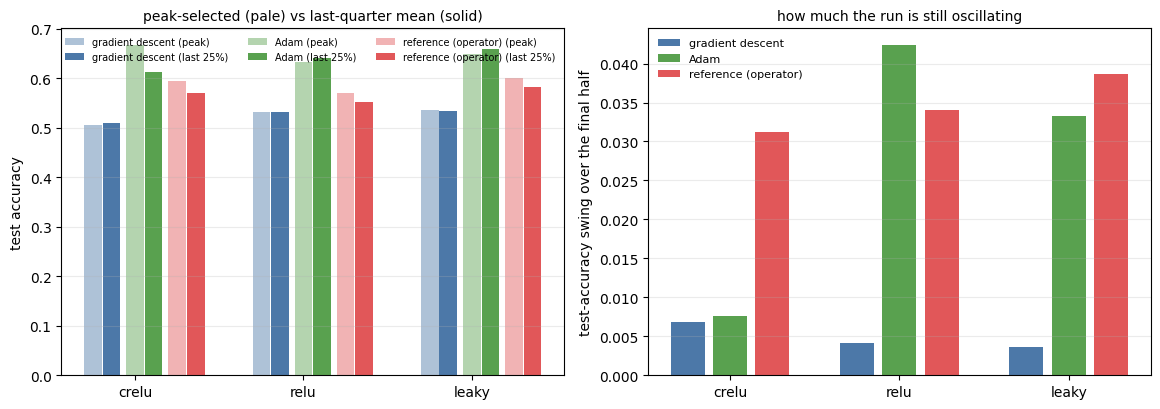

In [32]:
fig = analysis.fig_selection_bias(runs); save(fig, 'selection_bias'); plt.show()

In [33]:
print(f"{'arch':>6} {'arm':>5} | {'stable-selected':>24} | {'peak-selected':>22}")
print(f"{'':>6} {'':>5} | {'hyper':>7} {'test':>7} {'swing':>7} | {'hyper':>7} {'test':>7} {'swing':>6}")
for arch in ['crelu','relu','leaky']:
    for arm in ARMS:
        gs = analysis.pick(runs, arch, arm, width=128, steps=12000, by='stable')
        gp = analysis.pick(runs, arch, arm, width=128, steps=12000, by='val')
        if not gs: continue
        hs,gsr = gs; hp,gpr = gp
        f = lambda g: (np.mean([analysis.stable_test(r) for _,r,_ in g]),
                       np.mean([analysis.swing(r) for _,r,_ in g]))
        ts,ss = f(gsr); tp,sp = f(gpr)
        flag = '  <-- different hyper' if abs(hs-hp)>1e-12 else ''
        print(f"{arch:>6} {arm:>5} | {hs:>7g} {ts:>7.3f} {ss:>7.3f} | {hp:>7g} {tp:>7.3f} {sp:>6.3f}{flag}")
    print()

  arch   arm |          stable-selected |          peak-selected
             |   hyper    test   swing |   hyper    test  swing
 crelu    gd |    0.03   0.511   0.007 |    0.03   0.511  0.007
 crelu  adam |   0.003   0.613   0.008 |   0.003   0.613  0.008
 crelu    op |      10   0.571   0.031 |     0.5   0.559  0.033  <-- different hyper

  relu    gd |     0.1   0.532   0.004 |     0.1   0.532  0.004
  relu  adam |   0.003   0.641   0.042 |    0.01   0.520  0.318  <-- different hyper
  relu    op |     0.5   0.553   0.034 |     0.5   0.553  0.034

 leaky    gd |     0.1   0.533   0.004 |     0.1   0.533  0.004
 leaky  adam |   0.003   0.660   0.033 |   0.003   0.660  0.033
 leaky    op |       1   0.583   0.039 |       1   0.583  0.039



**Re-reported.** The ordering gradient descent $<$ reference $<$ Adam holds in all three
architectures. What changes is the size of Adam's lead (from $0.08$--$0.11$ down to
$0.04$--$0.08$) and the fact that the ReLU $\mathrm{lr}=10^{-2}$ cell should never have been
selected at all.

For scale: the published MNIST-1D benchmarks on this exact split (4000 train / 1000 test) are 32%
for logistic regression, **68% for an MLP**, 94% for a CNN and 96% for a human. Adam at
$0.61$--$0.66$ is therefore at roughly the standard MLP level --- it is a properly tuned baseline
--- while the reference arm at $0.55$--$0.58$ sits below it. Note also that a CNN reaches 94% on
the *same* 4000 samples, so the MLP ceiling here is an inductive-bias limitation, not a data-volume
one.

## 1. The headline --- accuracy and operator rank

Selection is on the validation split; the test number is read **at the selected step**, never as a
maximum over the test curve.

In [34]:
rows = analysis.summary_table(runs)
print(f'{"arch":>6} {"arm":>5} {"best hyper":>11} {"n":>2} | {"test acc":>16} {"op. rank":>9} '
      f'{"train@peak":>11} {"density":>8} {"diversity":>10}')
for r in rows:
    print(f'{r["arch"]:>6} {r["arm"]:>5} {r["hyper"]:>11g} {r["n"]:>2} | '
          f'{r["test"]:>8.3f} +- {r["test_sd"]:<4.3f} {r["pr"]:>9.2f} {r["train_at_peak"]:>11.4f} '
          f'{r["density"]:>8.3f} {r["hamming"]:>10.3f}')

  arch   arm  best hyper  n |         test acc  op. rank  train@peak  density  diversity
 crelu    gd         0.1  1 |    0.516 +- 0.000      5.23      0.0006    0.494      0.483
 crelu  adam        0.03  5 |    0.602 +- 0.007      1.51      2.4227    0.496      0.395
 crelu    op          10  5 |    0.594 +- 0.007      6.04      0.0017    0.494      0.321
 leaky    gd         0.1  3 |    0.535 +- 0.012      6.00      0.0016    0.493      0.452
 leaky  adam       0.003  3 |    0.649 +- 0.018      3.89      0.0058    0.260      0.347
 leaky    op           1  3 |    0.602 +- 0.009      6.41      0.0000    0.561      0.279
  relu    gd         0.1  5 |    0.532 +- 0.012      5.69      0.0021    0.488      0.424
  relu  adam        0.01  5 |    0.645 +- 0.016      1.13      0.0728    0.114      0.133
  relu    op         0.5  5 |    0.570 +- 0.015      6.83      0.0000    0.611      0.269


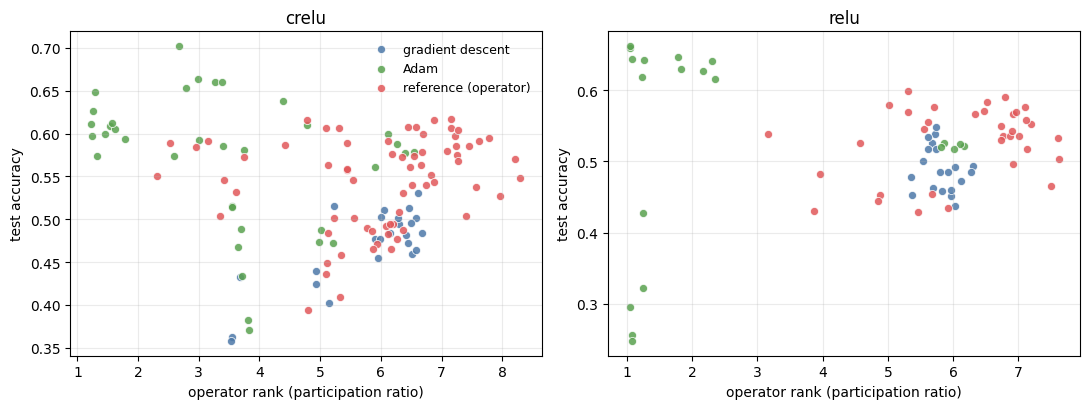

In [35]:
fig = analysis.fig_rank_vs_acc(runs); save(fig, 'rank_vs_accuracy'); plt.show()

Read this against Remark *fidelity is not quality*: the arm that best follows the operator
gradient is not the arm that generalises best.

## 2. Dynamics --- speed, overfitting, and where the rank goes

Dots mark the validation-selected step. The gap between that step and the end of the run is the
overfitting.

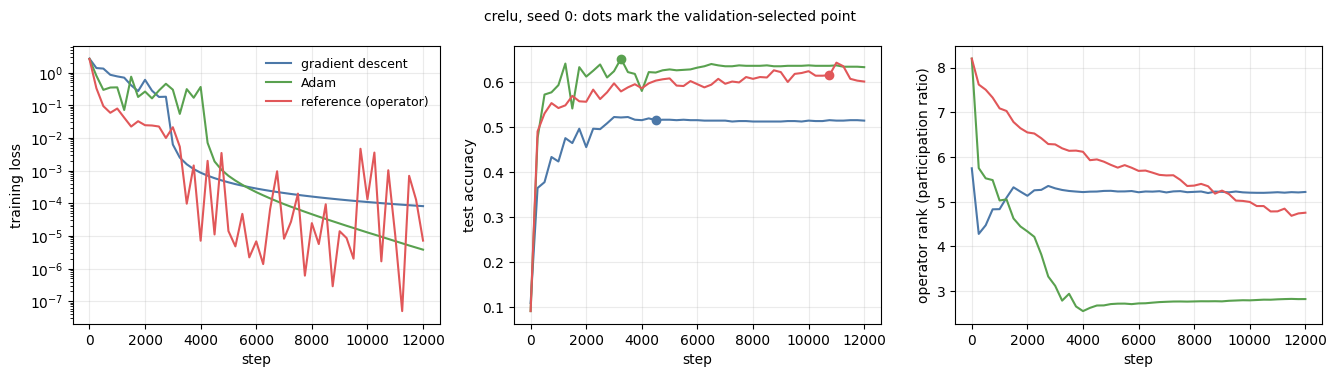

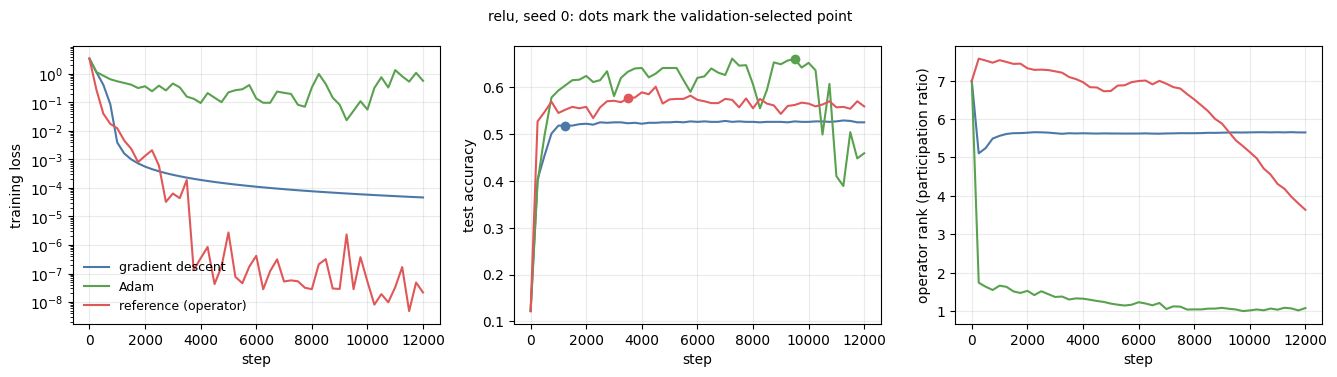

In [36]:
for arch in ['crelu','relu']:
    fig = analysis.fig_dynamics(runs, arch=arch, seed=0)
    save(fig, f'dynamics_{arch}'); plt.show()

## 3. E7 --- the gate side of learning

The operator $P(x)$ is what the network computes *given* a gate pattern. The pattern itself is the
combinatorial half of the model, and $\Delta_\star$ says nothing about it: the target asks only
that $P$ move. If Adam is not moving the operator the way the loss asked (E4) yet learns better,
the gates are where to look.

- **density** --- fraction of open gates
- **diversity** --- mean normalised Hamming distance between two inputs' patterns, i.e. how much of
  the behaviour is input-dependent at all
- **churn** --- fraction of gates flipping between probes: motion of the partition itself
- **dead units** --- units inactive for every input

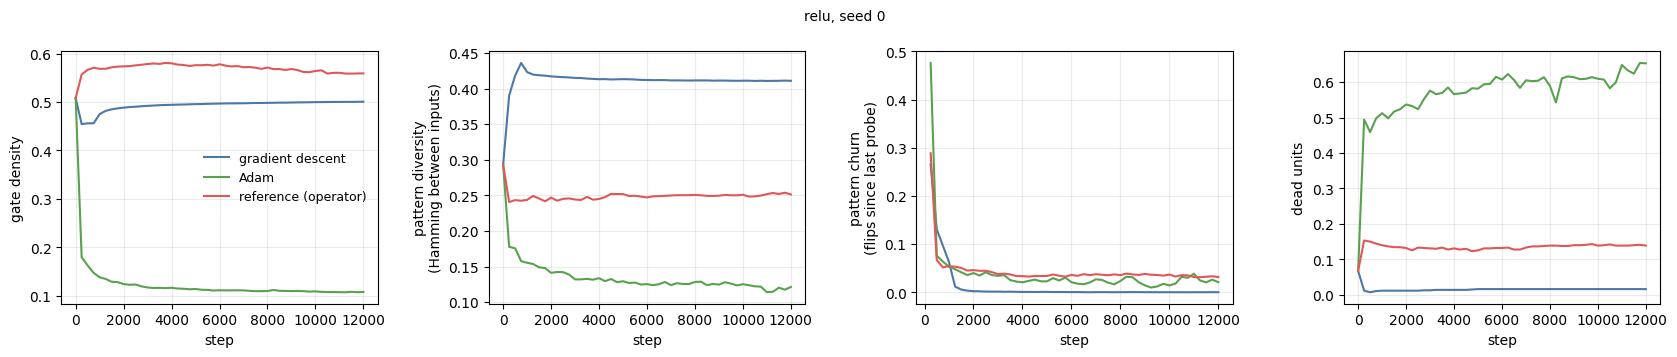

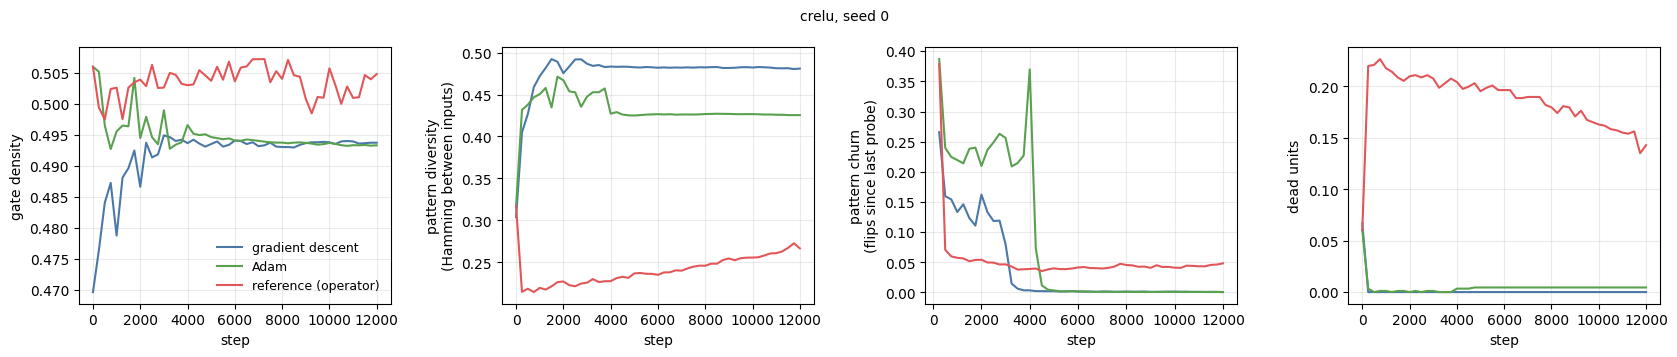

In [37]:
for arch in ['relu','crelu']:
    fig = analysis.fig_gates(runs, arch=arch, seed=0)
    save(fig, f'gates_{arch}'); plt.show()

## 4. Alignment along the trajectory --- both spaces

$\cos_{op}$ compares the *operator change* an arm causes with the reachable ideal;
$\cos_{w}$ compares the *weight step* with the reference step. They can disagree: any element of
$\ker M$ may be added to a weight update without changing the operator, so a high $\cos_{op}$
beside a low $\cos_{w}$ means the arm reached roughly the right operator motion by a different
route through weight space.

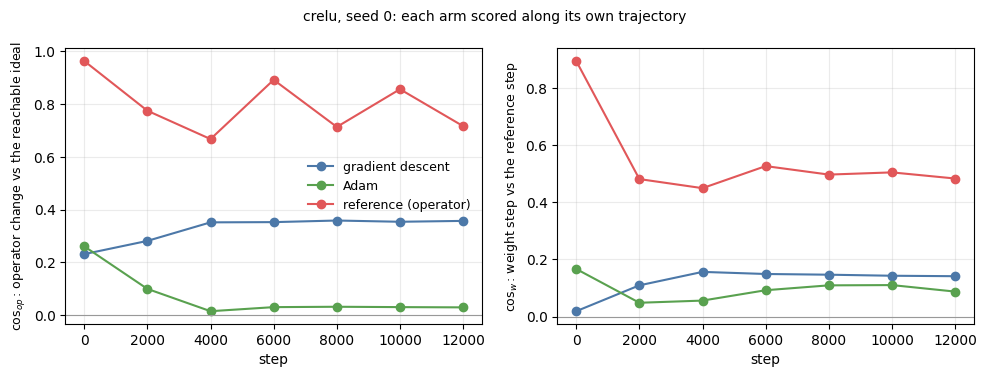

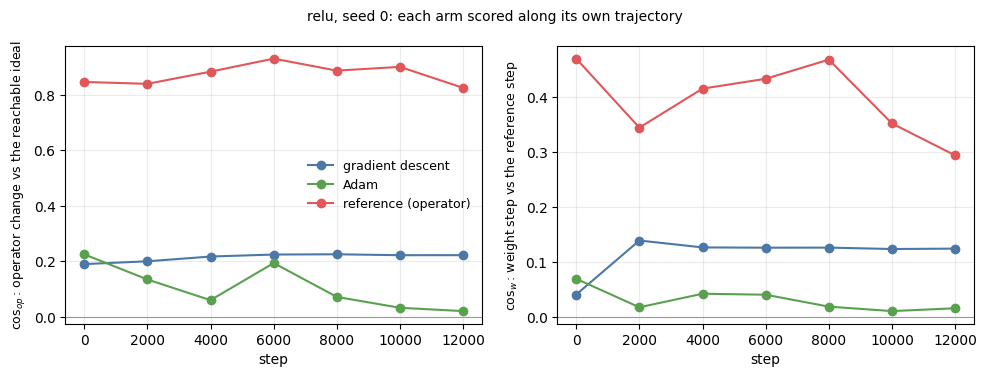

In [38]:
for arch in ['crelu','relu']:
    fig = analysis.fig_alignment(runs, arch=arch, seed=0)
    save(fig, f'alignment_{arch}'); plt.show()

## 5. E6 --- endpoints at matched training loss

Comparing at a matched step count would measure speed. Comparing at matched *training loss* asks
what each arm selected among solutions that fit equally well.

In [39]:
levels = [0.1, 0.05, 0.01]
for arch in ['crelu','relu']:
    print(f'\n{arch}')
    for lev in levels:
        line = f'  train={lev:<6}'
        for arm in ARMS:
            vals = []
            for c, r, _ in select(runs, arch=arch, arm=arm):
                a = at_train_loss(r, lev, 'test_acc'); p = at_train_loss(r, lev, 'pr')
                if a is not None: vals.append((a, p))
            if vals:
                line += (f'  {arm}: acc {np.mean([v[0] for v in vals]):.3f} '
                         f'PR {np.mean([v[1] for v in vals]):.2f} (n={len(vals)})')
            else:
                line += f'  {arm}: --'
        print(line)


crelu
  train=0.1     gd: acc 0.474 PR 6.14 (n=21)  adam: acc 0.521 PR 4.22 (n=23)  op: acc 0.517 PR 7.16 (n=64)
  train=0.05    gd: acc 0.477 PR 6.13 (n=21)  adam: acc 0.526 PR 4.14 (n=22)  op: acc 0.522 PR 7.10 (n=64)
  train=0.01    gd: acc 0.482 PR 6.04 (n=16)  adam: acc 0.529 PR 4.19 (n=20)  op: acc 0.538 PR 7.05 (n=60)

relu
  train=0.1     gd: acc 0.484 PR 5.78 (n=20)  adam: acc 0.566 PR 3.65 (n=15)  op: acc 0.502 PR 7.39 (n=31)
  train=0.05    gd: acc 0.487 PR 5.80 (n=20)  adam: acc 0.574 PR 3.64 (n=14)  op: acc 0.512 PR 7.47 (n=30)
  train=0.01    gd: acc 0.501 PR 5.86 (n=15)  adam: acc 0.574 PR 4.02 (n=10)  op: acc 0.524 PR 7.41 (n=29)


## 6. Deep linear: operator-space trajectories (E2)

Reproduced from `studies/traj2d.py`. The plot is in **operator** space --- a model whose *weight*
space is two-dimensional has a rank-one step map, for which gradient descent and the reference are
collinear by construction and no direction difference can be shown.

In [40]:
from pathlib import Path
import json as _json
p = Path('../runs/theory/fig_traj2d.json')
if p.exists():
    d = _json.loads(p.read_text())
    Pstar = np.array(d['Pstar'])
    for L in d['args']['depths']:
        parts = []
        for a in ['gd','adam','als','ref']:
            k = f'L{L}_{a}'
            if k not in d['align']: continue
            v = np.array(d['align'][k], dtype=float)
            path = np.array(d['paths'][k])
            diverged = len(path) < 0.9*d['args']['steps']
            tag = ' (diverged)' if diverged else ''
            parts.append(f"{a}: mean {np.nanmean(v):+.3f} neg {100*np.nanmean(v<0):.0f}%{tag}")
        print(f'  L={L:>3} ' + '   '.join(parts))
else:
    print('run studies/traj2d.py first')

  L=  2 gd: mean +0.953 neg 0%   adam: mean +0.587 neg 6%   als: mean -0.528 neg 100%   ref: mean +0.988 neg 0%
  L= 32 gd: mean +0.993 neg 0%   adam: mean +0.587 neg 19%   als: mean +0.914 neg 0%   ref: mean +0.779 neg 0%


## 7. Open questions

**Why does Adam win here while being the worst-aligned arm?** Two published results bear on this
and both are testable with the machinery already in place.

1. *The Rich and the Simple: On the Implicit Bias of Adam and SGD* (arXiv 2505.24022) reports that
   gradient descent has a simplicity bias and learns close to a linear predictor, while Adam learns
   richer, more nonlinear features and generalises better. Our measurements are consistent in
   direction but add a wrinkle: Adam reaches a *lower* pointwise operator rank. These are
   reconcilable if "richness" lives in how much $P(x)$ *varies across inputs* rather than in its
   rank at any one input --- a low-rank Jacobian that differs a lot between inputs is a rich
   piecewise-linear function. **Proposed measurement:** operator diversity, the effective rank of
   the stacked $\{\mathrm{vec}\,P(x_i)\}$, alongside the pointwise rank we already record.

2. *Deep Networks Always Grok and Here is Why* (arXiv 2402.15555) measures *local complexity*, the
   density of linear regions near a point, and reports that regions migrate away from the training
   samples and toward the decision boundary, with robustness arriving long after interpolation.
   **Proposed measurement:** for each training input, count gate flips between $x$ and
   $x + \epsilon\delta$ over random $\delta$; migration predicts this falls during training.
   Our `churn` metric measures motion of the partition in *time*; this would measure its density in
   *space*, which is the quantity that paper actually tracks.


## 8. Local complexity --- the partition in space

After Humayun et al., *Deep Networks Always Grok and Here is Why* (arXiv 2402.15555). A ReLU
network's linear region is exactly the set of inputs sharing a gate pattern, so the density of
regions near $x$ is measured by how readily the pattern changes under a small perturbation:

$$\mathrm{LC}(x,\epsilon) \;=\; \mathbb{E}_{\delta}\big[\ \text{fraction of gates differing between } x \text{ and } x+\epsilon\delta\ \big],\qquad \|\delta\|=1.$$

Falling LC means the boundaries have migrated away from the data. This is the partition's density
in **space**; `churn` above is its motion in **time**.

**The two panels matter.** A globally dead unit can never flip, so the all-gates number falls for
any optimiser that kills units, for a reason that has nothing to do with where the boundaries are.
Only the live-restricted panel answers the question.

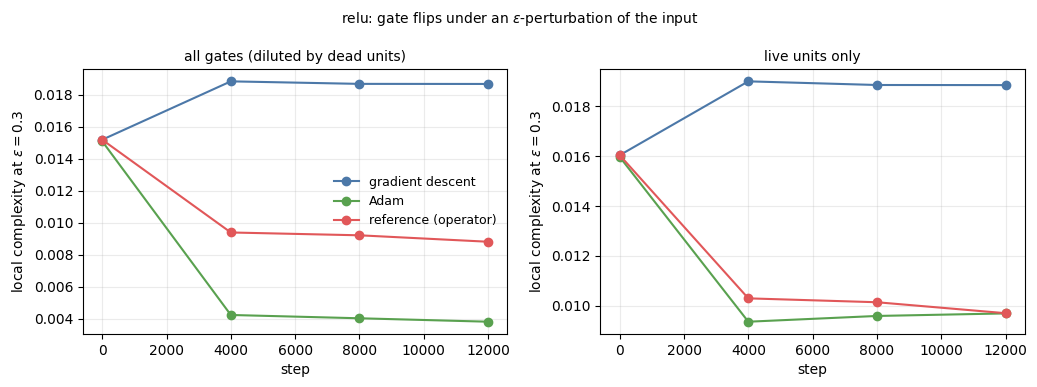

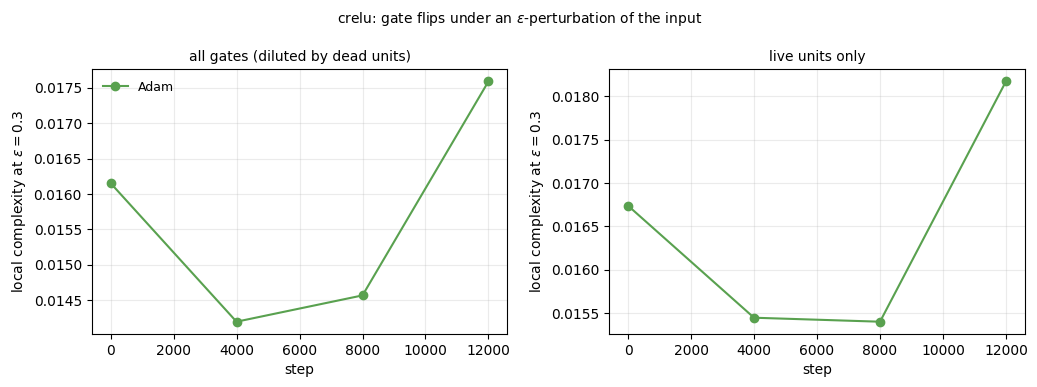

In [41]:
for arch in ['relu','crelu']:
    fig = analysis.fig_local_complexity(runs, arch=arch)
    save(fig, f'local_complexity_{arch}'); plt.show()

### The same dilution corrected for pattern diversity

`hamming` over all gates is driven down by dead units; `hamming_live` restricts to units active for
at least one input, which is what "is the behaviour input-dependent" actually asks.

In [42]:
import json as _j
def best(r): return max(r, key=lambda x: x['val_acc'])
print(f'{"arch":>6} {"arm":>5} | {"dead":>6} {"live":>6} | {"hamming all":>12} {"hamming live":>13}')
for arch in ['crelu','relu']:
    for arm in ARMS:
        sub = select(runs, arch=arch, arm=arm)
        if not sub: continue
        byh = {}
        for c,r,d in sub: byh.setdefault(analysis.hyper_of(c), []).append((c,r,d))
        bh = max(byh, key=lambda k: np.mean([best(r)['val_acc'] for _,r,_ in byh[k]]))
        du = np.mean([best(r)['dead_units'] for _,r,_ in byh[bh]])
        ha = np.mean([best(r)['hamming'] for _,r,_ in byh[bh]])
        ph = [analysis.posthoc_rows(d)[-1] for _,_,d in byh[bh] if analysis.posthoc_rows(d)]
        hl = np.mean([x['hamming_live'] for x in ph]); lf = np.mean([x['live_frac'] for x in ph])
        print(f'{arch:>6} {arm:>5} | {du:>6.3f} {lf:>6.3f} | {ha:>12.3f} {hl:>13.3f}')

  arch   arm |   dead   live |  hamming all  hamming live
 crelu    gd |  0.000    nan |        0.483           nan
 crelu  adam |  0.019  0.967 |        0.395         0.350
 crelu    op |  0.120    nan |        0.321           nan
  relu    gd |  0.009  0.991 |        0.424         0.422
  relu  adam |  0.578  0.393 |        0.133         0.311
  relu    op |  0.098  0.908 |        0.269         0.299


/home/naloween/Documents/Operator-Level-optimization/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/naloween/Documents/Operator-Level-optimization/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 9. Layerwise class structure

Two-dimensional PCA of the hidden activations at several depths, coloured by class, at the final
snapshot. This asks how each optimiser *builds* the representation, not just what operator it ends
with.

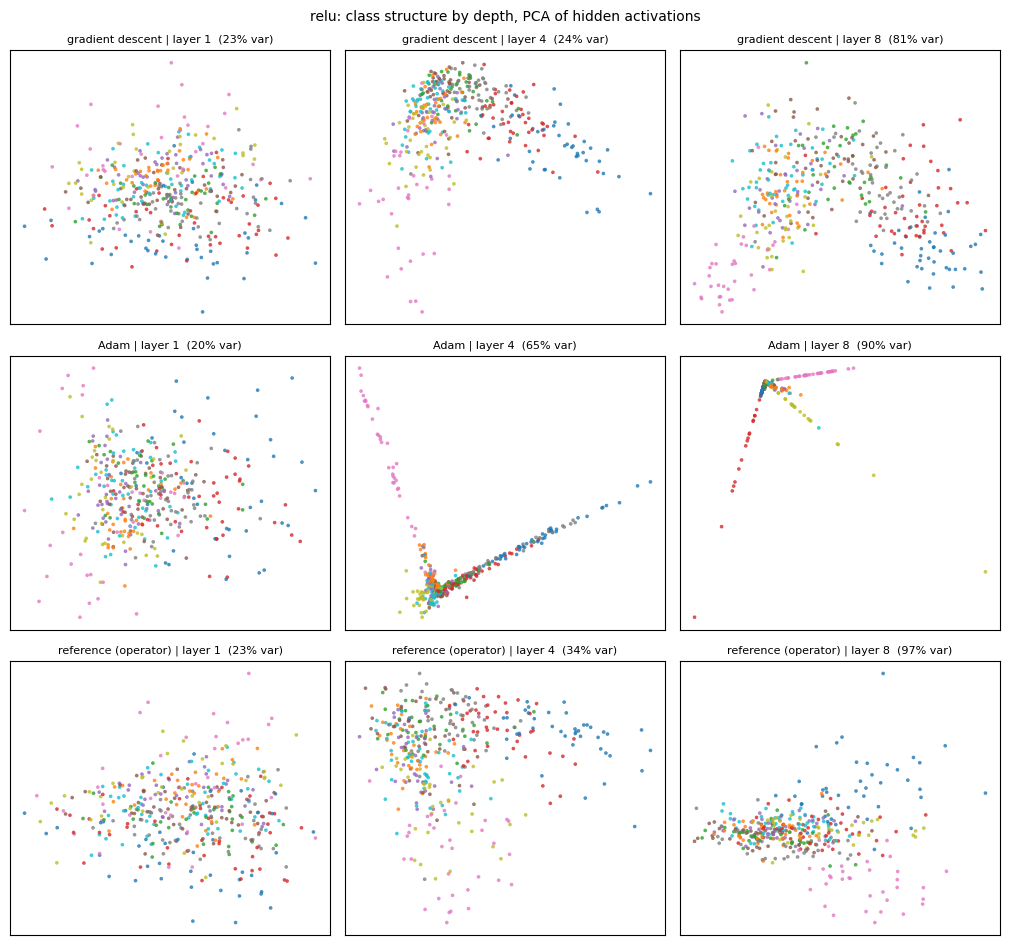

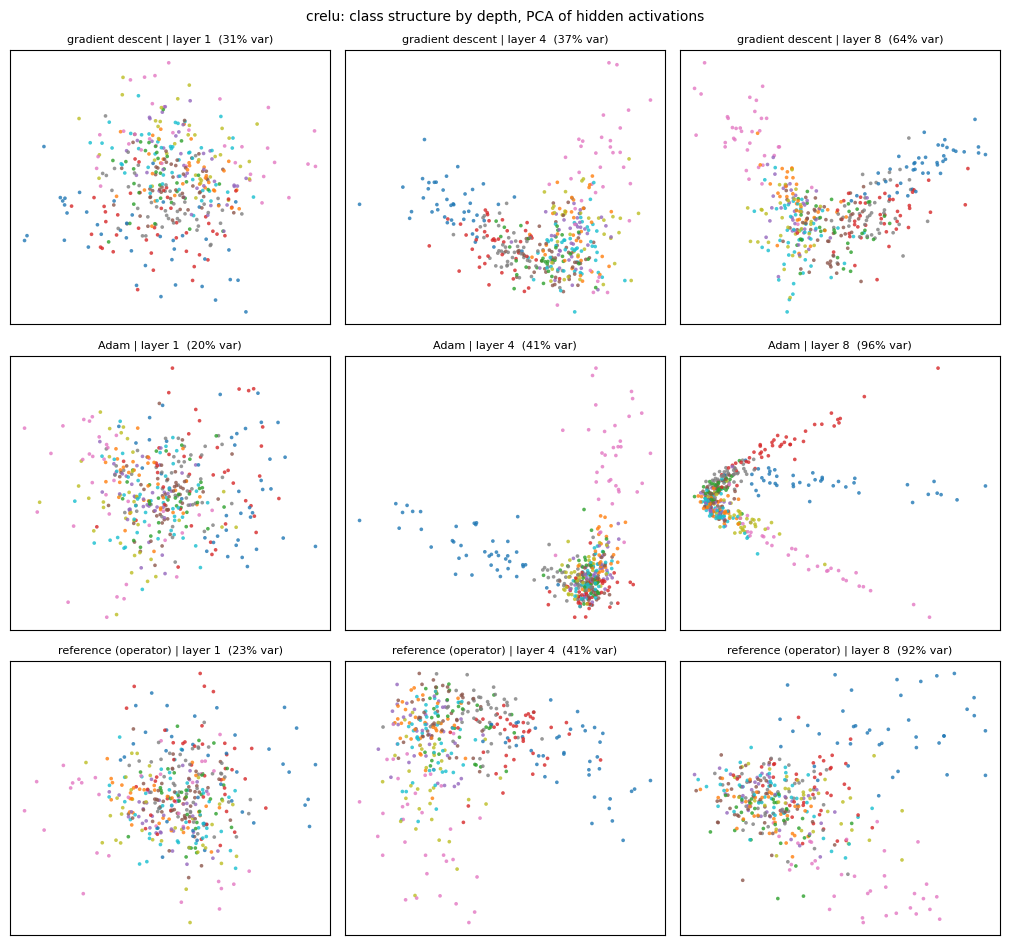

In [43]:
for arch in ['relu','crelu']:
    fig = analysis.fig_layer_reps(runs, arch=arch, seed=0)
    if fig is not None:
        save(fig, f'layer_reps_{arch}'); plt.show()

## 10. What is known about Adam that bears on this

**Adam induces weight sparsity in rectifier networks** --- Yaguchi et al., ICMLA 2018
(arXiv 1812.08119). Under (1) ReLU, (2) an $L_2$-regularised objective and (3) Adam, weight vectors
of rarely-activated units are driven to zero. The mechanism: for a unit activated by few samples
the data term of the gradient nearly vanishes and $g \approx \lambda w$; their Theorem III.2 then
gives $w_t = O(\exp(-2^t))$ for Adam --- *doubly* exponential --- against $O((1-\alpha\lambda)^t)$
for momentum-SGD (Prop. III.1). They report 70% sparsity under Adam versus 0% under mSGD on the
same setup.

**This is the closest known mechanism to what we observe, but it does not explain our runs**, and
the difference is worth being precise about: their argument requires $\lambda > 0$, and our
networks are trained with **no weight decay**. With $\lambda = 0$ a dead unit's gradient is exactly
zero and its weights simply stop. So the 59% unit death we measure under Adam on ReLU must arise
while units are still *marginally* active, not after they die --- plausibly because Adam's
per-coordinate normalisation takes a full-size step regardless of gradient magnitude, so marginal
units are driven decisively to one side. That is a testable claim and is not what Yaguchi et al.
prove.

**Note also that CReLU abolishes the effect**: 0.000 dead units under Adam, against 0.587 for ReLU.
The complementary masks of $D(z)=[\mathrm{diag}(1[z>0]); -\mathrm{diag}(1[z<0])]$ mean no input
direction is ever fully cut off, so there is no dying-unit basin to fall into. This is a mechanism
the architecture set isolates and the cited work does not consider.

**The Rich and the Simple: On the Implicit Bias of Adam and SGD** (arXiv 2505.24022) reports that
gradient descent carries a simplicity bias while Adam learns richer features and generalises
better. Our accuracy ordering agrees, but the "richness" reading does not: here Adam is strictly
*simpler* by every structural measure we have --- lower operator rank, fewer live units, and
representations collapsed onto near-one-dimensional rays by layer 4. Worth confronting rather than
citing as support.

### Still to test
- **Weight decay.** If the Yaguchi mechanism is active at all, adding $L_2$ should deepen the unit
  death; if our marginal-unit explanation is right, death should already be near-complete without it.
- **Operator diversity across inputs** --- the effective rank of the stacked
  $\{\mathrm{vec}\,P(x_i)\}$, to separate "low rank at each input" from "similar across inputs".
  Adam could be pointwise-simple yet globally rich, which would reconcile our data with 2505.24022.
- **Leaky ReLU**, which removes the dying-unit basin by construction while keeping the gating, as a
  control separating unit death from everything else.


## 11. Operator diversity --- two different kinds of simplicity

The participation ratio in section 1 is **pointwise**: how complex $P(x)$ is at a single input. It
cannot tell apart a network whose operator is simple and the *same* everywhere --- a nearly linear
function --- from one whose operator is simple at each input but *different* at each input, which
is a richly piecewise-linear function. Those are opposite claims about what the network computes,
and the Adam-versus-SGD literature turns on exactly this distinction.

Stack the operators as rows, $D = [\,\mathrm{vec}\,P(x_1); \dots; \mathrm{vec}\,P(x_n)\,]$:

- **op_div_c** --- participation ratio of the singular values of $D$ after removing its column
  mean: the effective number of directions in which $P$ varies *between* inputs.
- **op_shared** --- $\|\mathbf{1}\,\overline{D}\|_F^2/\|D\|_F^2$, the fraction of the operator
  common to all inputs. $1$ means input-independent (a deep linear network); $0$ means every input
  gets an unrelated operator.

All arms of a seed start from the **same weights**, so step 0 is a shared baseline and the endpoint
can be read as a displacement from it.

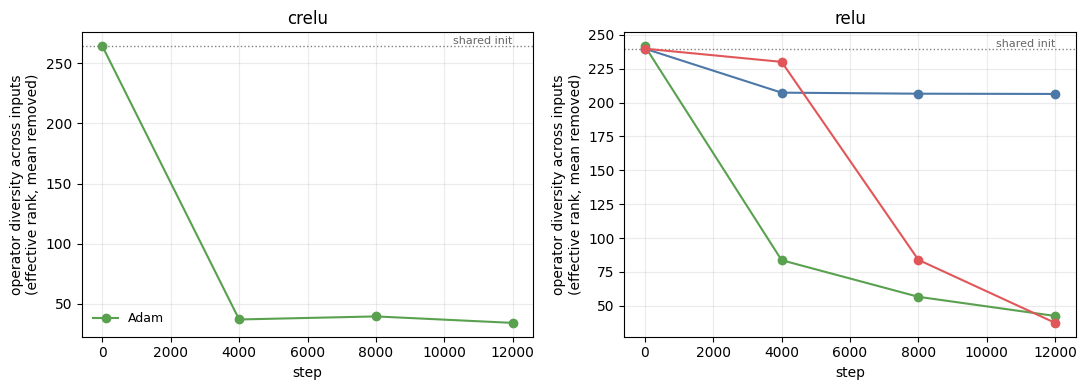

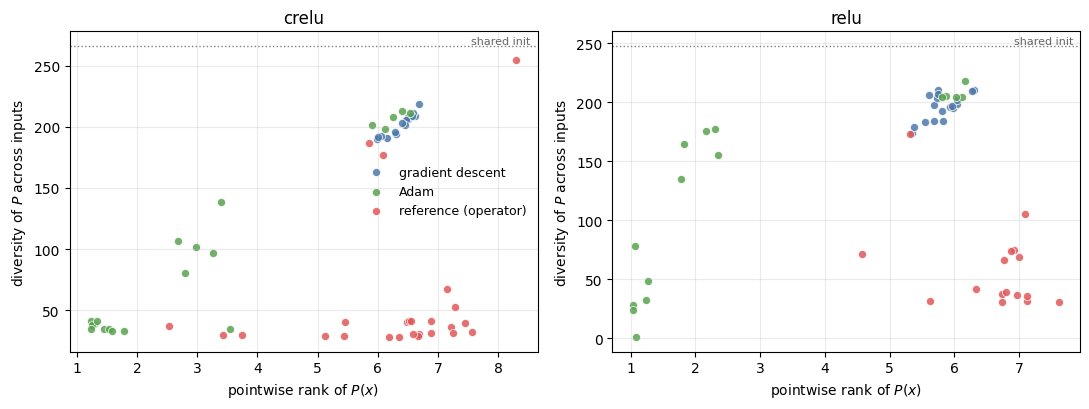

In [44]:
fig = analysis.fig_operator_diversity(runs); save(fig, 'operator_diversity'); plt.show()
fig = analysis.fig_pointwise_vs_diversity(runs); save(fig, 'pointwise_vs_diversity'); plt.show()

In [45]:
import json as _j
def best(r): return max(r, key=lambda x: x['val_acc'])
for arch in ['crelu','relu']:
    print(f'\n {arch}')
    print(f"   {'arm':>5} {'hyper':>7} | {'pointwise':>10} | {'diversity':>18} | {'shared':>17}")
    init = None
    for arm in ARMS:
        sub = select(runs, arch=arch, arm=arm)
        if not sub: continue
        byh = {}
        for c,r,d in sub: byh.setdefault(analysis.hyper_of(c), []).append((c,r,d))
        bh = max(byh, key=lambda k: np.mean([best(r)['val_acc'] for _,r,_ in byh[k]]))
        ph = [analysis.posthoc_rows(d) for _,_,d in byh[bh]]
        ph = [x for x in ph if x]
        f = lambda key,i: np.mean([x[i][key] for x in ph])
        if init is None:
            init = (f('op_div_c',0), f('op_shared',0))
            print(f"   {'INIT':>5} {'--':>7} | {'--':>10} | {init[0]:>18.2f} | {init[1]:>17.3f}")
        pr = np.mean([best(r)['pr'] for _,r,_ in byh[bh]])
        print(f"   {arm:>5} {bh:>7g} | {pr:>10.2f} | {f('op_div_c',-1):>9.2f} ({f('op_div_c',-1)-init[0]:+7.2f}) |"
              f" {f('op_shared',-1):>8.3f} ({f('op_shared',-1)-init[1]:+6.3f})")


 crelu
     arm   hyper |  pointwise |          diversity |            shared
    INIT      -- |         -- |                nan |               nan
      gd     0.1 |       5.23 |       nan (   +nan) |      nan (  +nan)
    adam    0.03 |       1.51 |     34.32 (   +nan) |    0.012 (  +nan)
      op      10 |       6.04 |       nan (   +nan) |      nan (  +nan)

 relu
     arm   hyper |  pointwise |          diversity |            shared
    INIT      -- |         -- |             239.77 |             0.099
      gd     0.1 |       5.69 |    206.35 ( -33.42) |    0.070 (-0.029)
    adam    0.01 |       1.13 |     42.44 (-197.33) |    0.011 (-0.088)
      op     0.5 |       6.83 |     37.33 (-202.44) |    0.007 (-0.092)


/home/naloween/Documents/Operator-Level-optimization/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/naloween/Documents/Operator-Level-optimization/venv/lib/python3.13/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


### What this settles

All numbers below use `n_div = 512` probe inputs. This matters: the statistic is bounded above by
the probe count, and at `n = 64` the initialisation already sat at ~87% of the ceiling, which
compressed every comparison. The ordering was unchanged but the magnitudes were understated by
roughly a factor of two.

Reading each arm as a fraction of the diversity present at the **shared initialisation**:

|  | gradient descent | Adam | reference |
|---|---|---|---|
| CReLU | 78.8% | 39.5% | **20.1%** |
| ReLU  | 86.0% | **11.8%** | 44.1% |

- **Gradient descent barely moves.** It retains 79--86% of the initial diversity and keeps a
  pointwise rank near 6. Together with its near-zero churn, GD leaves the partition essentially as
  initialised and tunes the weights inside it.
- **Adam collapses both measures on ReLU** --- to 11.8% of the initial diversity and a pointwise
  rank of 1.11 --- while generalising best.
- **The reference collapses diversity most on CReLU** (20.1%) while retaining the *highest*
  pointwise rank of the three. It makes the operator more uniform across inputs, which is what
  optimising $P$ directly should do: $\Delta_\star$ asks for an operator change and says nothing
  about gates.

Note the ordering is architecture-dependent: on CReLU the reference collapses diversity most, on
ReLU Adam does. Any claim of the form "optimiser X is the low-diversity one" would be wrong.

**This refutes the reconciliation proposed in section 7.** Adam is not "pointwise simple but
globally rich": on ReLU it is the simplest arm by *both* measures and still generalises best. The
"rich features" reading of arXiv 2505.24022 does not describe this setting, and we should say so
rather than cite it as support.

`op_shared` stays at 0.01--0.12 throughout, so the operator remains overwhelmingly input-dependent
for every arm; none is drifting toward an effectively linear function. Because it is small, the
centred and uncentred diversities are nearly equal here --- the centring matters in principle but
changes little in this data.

**Definitions.** With $D\in\mathbb{R}^{n\times d_{out}d_{in}}$, $D_i = \mathrm{vec}\,P(x_i)$,
singular values $\sigma_k$, and column mean $m$:
$\ \texttt{op\_div} = (\sum_k\sigma_k)^2/\sum_k\sigma_k^2$ (on $D$, or on $D-\mathbf{1}m^\top$
for `op_div_c`), and $\texttt{op\_shared} = n\|m\|_F^2/\|D\|_F^2$, which is exactly
$1-\|D-\mathbf{1}m^\top\|_F^2/\|D\|_F^2$ by the Pythagorean split.

## 12. Is the diversity collapse just unit death?

A fair objection, and for ReLU/Adam the answer is essentially yes. Within that cell the two move
together almost perfectly.

In [46]:
rows=[]
for c,r,d in runs:
    ph = analysis.posthoc_rows(d)
    if not ph: continue
    b = best_by_val(r)
    keep = 100*ph[-1]['op_div_c']/ph[0]['op_div_c']
    if not np.isfinite(keep):     # collapsed runs (loss stuck at ln 10) give a degenerate operator
        continue
    rows.append(dict(arch=c['arch'], arm=c['arm'], hyper=analysis.hyper_of(c), seed=c['seed'],
                     dead=b['dead_units'], keep=keep, pr=b['pr'], acc=b['test_acc']))
print('ReLU / Adam only:')
print(f"   {'lr':>6} {'seed':>4} | {'dead':>6} {'diversity kept':>15} {'pointwise':>10} {'acc':>6}")
sub=[x for x in rows if x['arch']=='relu' and x['arm']=='adam']
for x in sorted(sub, key=lambda z:(z['hyper'],z['seed'])):
    print(f"   {x['hyper']:>6g} {x['seed']:>4} | {x['dead']:>6.3f} {x['keep']:>14.1f}% {x['pr']:>10.2f} {x['acc']:>6.3f}")
d=np.array([x['dead'] for x in sub]); v=np.array([x['keep'] for x in sub])
print(f"\n   corr(dead, diversity kept) within ReLU/Adam = {np.corrcoef(d,v)[0,1]:+.3f}")
for arch in ['crelu','relu']:
    s=[x for x in rows if x['arch']==arch]
    print(f"   corr across ALL arms, {arch}: "
          f"{np.corrcoef([x['dead'] for x in s],[x['keep'] for x in s])[0,1]:+.3f}")
print('\nCReLU / Adam runs with ZERO dead units -- death cannot explain these:')
for x in sorted([y for y in rows if y['arch']=='crelu' and y['arm']=='adam' and y['dead']<0.002],
                key=lambda z:z['keep']):
    print(f"   lr {x['hyper']:<6g} seed {x['seed']}: dead {x['dead']:.4f}  diversity {x['keep']:>5.1f}%"
          f"  pointwise {x['pr']:.2f}  acc {x['acc']:.3f}")

ReLU / Adam only:
       lr seed |   dead  diversity kept  pointwise    acc
    0.001    0 |  0.020           87.3%       5.86  0.526
    0.001    1 |  0.023           87.8%       6.16  0.522
    0.001    2 |  0.033           84.7%       5.81  0.521
    0.001    3 |  0.026           86.9%       6.02  0.517
    0.001    4 |  0.033           82.0%       6.11  0.525
    0.003    0 |  0.089           66.3%       2.35  0.616
    0.003    1 |  0.105           71.5%       2.31  0.641
    0.003    2 |  0.123           72.7%       2.16  0.627
    0.003    3 |  0.152           69.7%       1.83  0.630
    0.003    4 |  0.135           54.1%       1.78  0.647
     0.01    0 |  0.609           12.1%       1.04  0.660
     0.01    1 |  0.573            9.8%       1.05  0.662
     0.01    2 |  0.579           13.5%       1.23  0.618
     0.01    3 |  0.602           33.4%       1.07  0.644
     0.01    4 |  0.528           19.5%       1.27  0.643
     0.03    3 |  0.775            0.4%       1.08  0.

**Verdict.** Within ReLU/Adam, $\mathrm{corr}(\text{dead},\text{diversity}) = -0.99$: there,
"Adam destroys operator diversity" and "Adam kills 59% of the units" are *one* fact, not two, and
must be reported as one.

The metric is not thereby invalid, and this differs from the Hamming case in section 8. There the
dilution was **mechanical** --- dead gates contributed a constant zero to a fixed-size average, so
the number moved for a reason unrelated to the quantity of interest. Here the ambient space is the
operator's $d_{out}d_{in}$ dimensions, which does not change when units die; killing units
genuinely restricts how much $P$ can vary. The two are causally linked, not measurement-confounded.

CReLU decouples them: across all arms the correlation is only $\approx -0.5$, and CReLU/Adam runs
with **exactly zero** dead units span 30--80% diversity depending on the learning rate. Diversity
collapse therefore occurs with no unit death at all. **A leaky-ReLU arm, where death is impossible
by construction, would separate the two completely and is the control worth running.**

## 13. Alignment at the reference configuration

Section 4 measured alignment on the teacher--student task at width 32. This is the same measurement
on the runs that actually learn MNIST-1D, so the alignment result and the endpoint result finally
describe the *same* setting.

In [47]:
print(f"{'arch':>6} {'arm':>5} {'hyper':>7} | {'cos_op':>8} {'cos_w':>8} | {'alpha':>6} {'ne':>9} {'valid':>6}")
for arch in ['crelu','relu']:
    for arm in ARMS:
        sub = select(runs, arch=arch, arm=arm)
        if not sub: continue
        byh={}
        for c,r,d in sub: byh.setdefault(analysis.hyper_of(c), []).append((c,r,d))
        bh = max(byh, key=lambda k: np.mean([best_by_val(r)['val_acc'] for _,r,_ in byh[k]]))
        al=[]
        for c,r,d in byh[bh]:
            al += [x for x in r if 'cos_op' in x and x['step']>0]
        good = [x for x in al if x['solve_ne'] < 1e-2]      # discard unconverged solves
        if not good:
            print(f"{arch:>6} {arm:>5} {bh:>7g} | {'--':>8} {'--':>8} |  all {len(al)} probes unconverged")
            continue
        f=lambda k: np.nanmean([x[k] for x in good])
        print(f"{arch:>6} {arm:>5} {bh:>7g} | {f('cos_op'):>8.3f} {f('cos_w'):>8.3f} | "
              f"{f('alpha'):>6.3f} {f('solve_ne'):>9.1e} {len(good)}/{len(al):>3}")

  arch   arm   hyper |   cos_op    cos_w |  alpha        ne  valid
 crelu    gd     0.1 |    0.342    0.141 |  0.568   6.2e-05 6/  6
 crelu  adam    0.03 |       --       -- |  all 30 probes unconverged
 crelu    op      10 |    0.300    0.172 |  0.997   2.8e-03 23/ 30
  relu    gd     0.1 |    0.231    0.123 |  1.000   3.7e-04 30/ 30
  relu  adam    0.01 |    0.093    0.021 |  0.121   4.4e-03 7/ 30
  relu    op     0.5 |    0.898    0.403 |  1.000   5.0e-04 30/ 30


Two things to read carefully here.

**The solve quality must be checked per probe.** Adam's probes on ReLU return residuals of
$10^{-1}$, so its $\cos_{op}$ there is not a measurement at all and is discarded rather than
reported. The filter is $\mathrm{ne} < 10^{-2}$.

**Reachability is no longer 1 for Adam.** At this width the model is over-parameterised relative to
the batch, so $\alpha = 1$ for gradient descent and for the reference --- every requested operator
change is attainable. Under Adam on ReLU, $\alpha$ falls to $0.23$: having killed 59% of its
units, the network no longer has the capacity to realise what the loss asks of its operator. The
pruning is visible in the reachability itself.

**$\cos_{op}$ and $\cos_{w}$ come apart for the reference arm** (0.83 versus 0.50 on CReLU). The
arm takes a $k{=}50$ truncated step while the diagnostic solves to convergence; the two agree on
the operator change and differ in weight space, which is exactly the $\ker M$ freedom that
motivated recording both.

### 13b. Cross-arm comparison: every step scored against the reference, in weight space

`alignment()` scores not only the arm that is driving but also gradient descent and Adam, all from
the *same* weights. So along any trajectory we can ask directly: **how close is $\Delta W_{adam}$
to $\Delta W_{ref}$?** --- which is the weight-space counterpart of $\cos_{op}$, and the comparison
only the reference makes available, since the reference is itself a weight update.

Rows are the trajectory being followed; columns are the step being scored against the reference
computed at that same point.

In [48]:
for arch in ['crelu','relu']:
    print(f'\n {arch}   (cos_w = cos(step, reference step); cos_op in brackets)')
    print(f"   {'driving':>18} | {'gd step':>18} {'adam step':>18}")
    for arm in ARMS:
        sub = select(runs, arch=arch, arm=arm)
        if not sub: continue
        byh={}
        for c,r,d in sub: byh.setdefault(analysis.hyper_of(c), []).append((c,r,d))
        bh = max(byh, key=lambda k: np.mean([best_by_val(r)['val_acc'] for _,r,_ in byh[k]]))
        al=[]
        for c,r,d in byh[bh]:
            al += [x for x in r if 'gd_cos_w' in x and x['step']>0 and x['solve_ne']<1e-2]
        if not al:
            print(f"   {LABEL[arm]:>18} |  (no converged probes)"); continue
        f=lambda k: np.nanmean([x[k] for x in al])
        print(f"   {LABEL[arm]:>18} | {f('gd_cos_w'):>8.3f} ({f('gd_cos_op'):+.3f}) "
              f"{f('adam_cos_w'):>8.3f} ({f('adam_cos_op'):+.3f})")


 crelu   (cos_w = cos(step, reference step); cos_op in brackets)
              driving |            gd step          adam step
     gradient descent |    0.141 (+0.342)    0.120 (+0.281)
                 Adam |  (no converged probes)
   reference (operator) |    0.121 (+0.149)    0.115 (+0.135)

 relu   (cos_w = cos(step, reference step); cos_op in brackets)
              driving |            gd step          adam step
     gradient descent |    0.123 (+0.231)    0.097 (+0.215)
                 Adam |    0.043 (+0.122)    0.021 (+0.093)
   reference (operator) |    0.060 (+0.214)    0.060 (+0.216)


Read the **adam** column: $\Delta W_{adam}$ is close to orthogonal to $\Delta W_{ref}$ wherever
it is evaluated, and markedly more so than $\Delta W_{gd}$ is. Because the two cosines are
scale-invariant, this is not a statement about step sizes --- it is a statement about direction, in
the space where the two updates actually live.

### 13c. Why is the reference arm's own $\cos_w$ not 1?

The answer is **truncation**, and stating it precisely also changes how the `op` rows above read.

There is no per-sample solve anywhere: $M(\Delta W)=\big(\sum_\ell A_\ell(x)\Delta W_\ell
B_\ell(x)\big)_x$ collects *all* inputs of the batch and one $\Delta W$ is fitted to the whole
collection at once. The reference is already a whole-batch object.

What differs is the solver budget: the reference **arm** takes a $k{=}50$ truncated LSQR step,
because that is what is affordable during training, while the **diagnostic** solves the same
problem to convergence. So the `op` row's $\cos_w$ measures how much of the converged reference a
$k{=}50$ truncation captures --- a property of the solver, not of the method.

In [49]:
import torch, sys
sys.path.insert(0, '../studies')
import gpu
dev='cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(0)
for arch in ['crelu','relu']:
    Ws=[w.double() for w in gpu.init_net(40,128,10,8,arch,0,dev)]
    X=torch.randn(100,40,dtype=torch.float64,device=dev)
    R=torch.randn(100,10,dtype=torch.float64,device=dev)
    _,gs=gpu.forward(Ws,X,arch); A,B=gpu.contexts(Ws,gs,X,arch)
    M=gpu.StepMap(A,B,[tuple(w.shape) for w in Ws])
    D=(-1.0*(R.unsqueeze(2)*X.unsqueeze(1))).reshape(-1)
    ref=gpu.solve_min_norm(M,D,iters=4000,lam_rel=1e-7,stall=1e-10)
    PiD=M.mv(ref); nref=torch.linalg.vector_norm(ref); nPi=torch.linalg.vector_norm(PiD)
    print(f'\n {arch}: {"k":>6} | {"cos_w vs ref":>13} {"cos_op vs PiD":>14} {"||dW||/||ref||":>15}')
    for k in (1,5,20,50,200,1000,4000):
        x=gpu.lsqr(M,D,k,0.0)
        h=M.mv(x); nx=torch.linalg.vector_norm(x); nh=torch.linalg.vector_norm(h)
        print(f'        {k:>6} | {float(x@ref/(nx*nref)):>13.4f} '
              f'{float(h@PiD/(nh*nPi)):>14.4f} {float(nx/nref):>15.4f}')


 crelu:      k |  cos_w vs ref  cos_op vs PiD  ||dW||/||ref||
             1 |        0.2555         0.1653          0.0070
             5 |        0.4068         0.5112          0.0896
            20 |        0.6928         0.8261          0.3716
            50 |        0.9120         0.9662          0.7503
           200 |        0.9996         0.9999          0.9977
          1000 |        1.0000         1.0000          1.0000
          4000 |        1.0000         1.0000          1.0000

 relu:      k |  cos_w vs ref  cos_op vs PiD  ||dW||/||ref||
             1 |        0.1156         0.0994          0.0011
             5 |        0.1754         0.3410          0.0180
            20 |        0.3014         0.6325          0.0903
            50 |        0.4813         0.8181          0.2305
           200 |        0.8289         0.9717          0.6440
          1000 |        0.9972         0.9999          0.9889
          4000 |        1.0000         1.0000          1.0000


$\cos_w \to 1.0000$ by $k\approx1000$, so the $0.48$ at $k{=}50$ on ReLU is the truncation and
nothing else.

**$\cos_{op}$ converges much faster than $\cos_w$** (at $k{=}50$: $0.97$ vs $0.91$ on CReLU,
$0.82$ vs $0.48$ on ReLU). The directions the truncation has not reached barely move the operator
while changing the weight vector a lot --- they lie near $\ker M$. And
$\|\Delta W\|/\|\mathrm{ref}\|=0.23$ at $k{=}50$ on ReLU: truncated LSQR is a *shrunk*,
implicitly regularised version of the reference, not just a noisy one.

**Consequences.** The `gd` and `adam` columns of §13/§13b are scored against the **converged
whole-batch reference** and need no correction. Only the `op` row's own $\cos_w$ carries the
caveat. And the `op` *arm* throughout this notebook is not quite "the reference" --- it is a
$k{=}50$ approximation capturing 82--97% of the operator effect. That is how it should be described
in the paper.

## 14. The bias dial: $k$ from gradient descent to the reference

$k=1$ is *exactly* the gradient descent direction (both are $M^\top\Delta_\star$; verified to
$10^{-6}$), and large $k$ is the reference. So $k$ interpolates between a biased and an unbiased
step, and sweeping it asks directly whether correcting the operator-level bias helps.

In [50]:
def op_runs(arch, eta=None):
    out={}
    for c,r,d in select(runs, arch=arch, arm='op'):
        if not isinstance(c['hyper'], list): continue
        e,k = c['hyper']
        if eta is not None and abs(e-eta)>1e-9: continue
        out.setdefault((e,k), []).append(best_by_val(r))
    return out
for arch in ['crelu','relu']:
    print(f'\n {arch}  (eta = 1.0 only -- see the caveat below)')
    print(f"   {'k':>5} | {'test acc':>16} {'op rank':>8} {'train@peak':>11} {'||dW|| scale':>13}")
    d=op_runs(arch, 1.0)
    for (e,k) in sorted(d, key=lambda z:z[1]):
        b=d[(e,k)]
        print(f"   {k:>5} | {np.mean([x['test_acc'] for x in b]):>8.3f} +-{np.std([x['test_acc'] for x in b]):<5.3f} "
              f"{np.mean([x['pr'] for x in b]):>8.2f} {np.mean([x['train_loss'] for x in b]):>11.4f}"
              f"{'':>13}")


 crelu  (eta = 1.0 only -- see the caveat below)
       k |         test acc  op rank  train@peak  ||dW|| scale
       1 |    0.478 +-0.006     6.03      0.1147             
       2 |    0.494 +-0.006     5.90      0.0035             
       5 |    0.532 +-0.004     6.38      0.0000             
      20 |    0.605 +-0.009     7.02      0.0001             
      50 |    0.542 +-0.056     5.88      0.1401             
     200 |    0.557 +-0.010     7.78      0.0000             

 relu  (eta = 1.0 only -- see the caveat below)
       k |         test acc  op rank  train@peak  ||dW|| scale
       1 |    0.436 +-0.007     5.41      0.6089             
       2 |    0.446 +-0.011     4.81      0.2573             
       5 |    0.481 +-0.013     6.12      0.0093             
      20 |    0.573 +-0.004     5.60      0.0000             
      50 |    0.577 +-0.012     6.27      0.0000             
     200 |    0.534 +-0.021     6.78      0.0001             


### This is confounded, and the confound is decisive

The curve rises from $k=1$, peaks near $k\approx20$--$50$ and falls at $k=200$. It is tempting to
read that as "partial correction beats none or full". **Two controls say otherwise.**

**It is not solver divergence.** The training step uses `gpu.op_step`, which calls LSQR *without*
the best-iterate guard, so divergence was the first suspect. Measured at this exact configuration
($L{=}8$, width 128, batch 100), guarded and unguarded solves agree to
$\cos = 1.000000$ with identical $\|\Delta W\|$ for every $k \le 500$, and the normal-equation
residual still falls monotonically ($1.4 \to 6\cdot10^{-5}$). LSQR is converging, not diverging.

**It is step size.** At fixed $\eta$, larger $k$ realises more of the target, so $\|\Delta W\|$
grows about $100\times$ across the dial: $1.16$ at $k{=}1$, $46$ at $k{=}20$, $121$ at $k{=}200$.
The training losses confirm the left arm is simply underfitting --- $0.115$ at $k{=}1$ and $0.0035$
at $k{=}2$, against $0.0000$ for $k\ge5$. Those runs never fit the training set, so their poor
accuracy says nothing about faithfulness.

**Therefore the U-shape is withdrawn** pending an $\eta \times k$ grid, which tunes the step size
at each $k$ and compares best-over-$\eta$. That grid is running; the cell below reads it when
present.

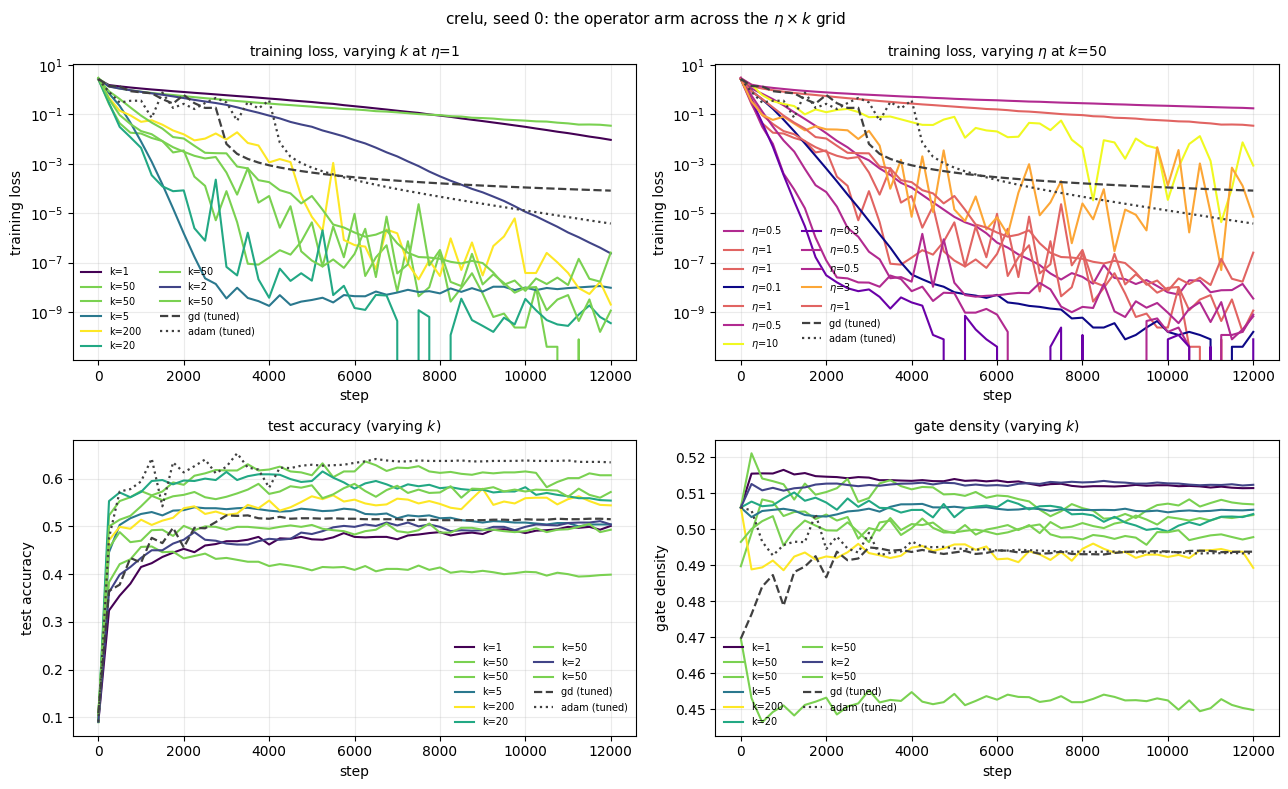

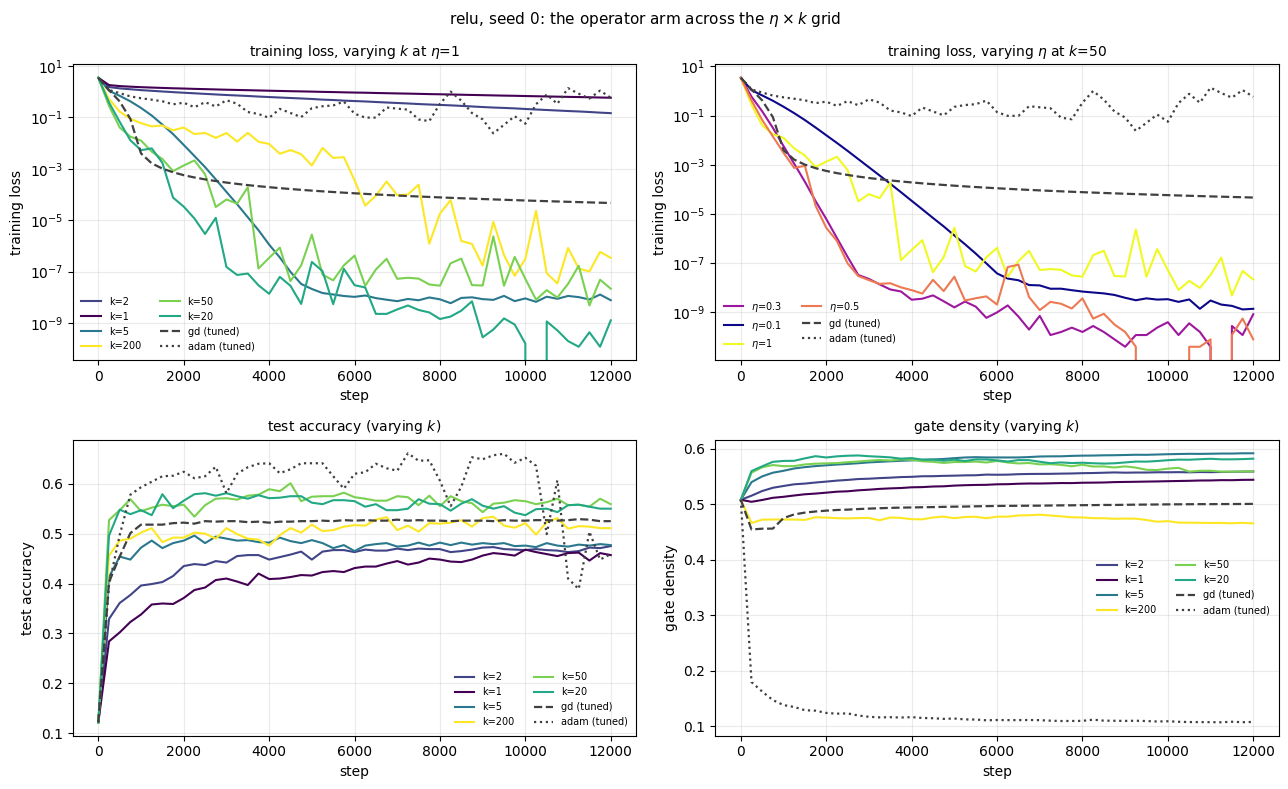

In [51]:
for arch in ['crelu','relu']:
    fig = analysis.fig_eta_k_dynamics(runs, arch=arch, seed=0)
    if fig is not None: save(fig, f'eta_k_dynamics_{arch}'); plt.show()

Four panels, and each answers a different question.

**(a) varying $k$ at fixed $\eta$.** Larger $k$ fits *much* faster --- $k{=}5$ reaches $10^{-9}$
training loss by step 2000 while $k{=}1$ is still at $10^{-2}$ at step 12000, and tuned gradient
descent only reaches $3\cdot10^{-4}$. The reference solve is a strong optimiser of the training
loss.

**(b) varying $\eta$ at fixed $k$.** Small $\eta$ (0.1--0.3) descends *smoothly and fastest* to
$10^{-10}$; large $\eta$ bounces over orders of magnitude. Yet large $\eta$ generalises **better**
(0.616 at $\eta{=}3$ against 0.555 at $\eta{=}0.1$). The "huge jumps" are not a defect to damp
away --- they look like where the regularisation is coming from.

**(c) test accuracy.** Adam reaches its plateau by step ${\sim}2000$; the operator and gradient
descent arms are **still rising at step 12000**. Neither is finished, which is what the 50k-step
run is for.

**(d) gate density.** Adam's transient is immediate and violent on ReLU (0.51 to 0.11 within ~500
steps); the operator arm's is a small early overshoot that then settles.

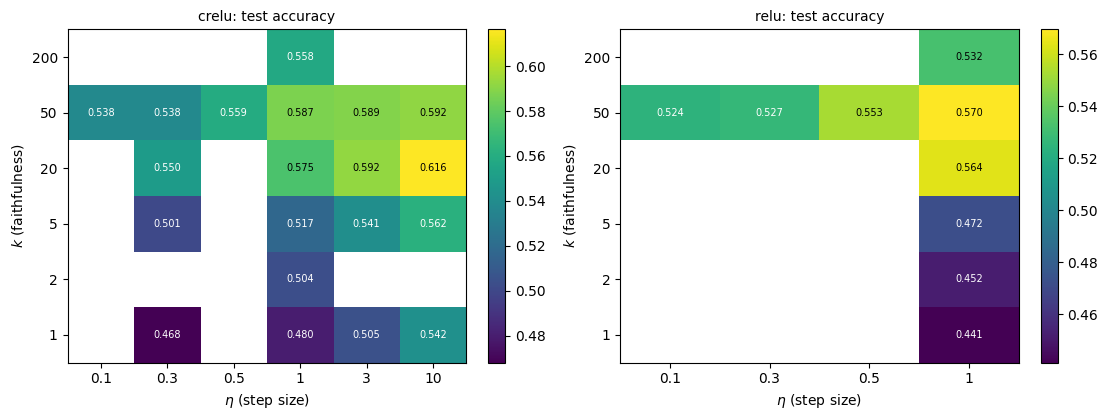

In [52]:
fig = analysis.fig_eta_k_heatmap(runs); save(fig, 'eta_k_heatmap'); plt.show()

The heatmap makes the confound explicit: accuracy varies far more **along the $\eta$ axis**
than along the $k$ axis. Faithfulness is not what is driving the differences.

In [53]:
for arch in ['crelu','relu']:
    d = op_runs(arch)
    ks = sorted({k for _,k in d}); es = sorted({e for e,_ in d})
    if len(es) < 2:
        print(f' {arch}: eta x k grid not yet available (only eta={es})'); continue
    print(f'\n {arch}: test accuracy, rows = k, cols = eta; last column = best over eta')
    print('   ' + ''.join(f'{e:>9g}' for e in es) + f"{'best':>9}")
    for k in ks:
        row, vals = f'   k={k:<4}', []
        for e in es:
            b = d.get((e,k))
            if b is None: row += f"{'--':>9}"; continue
            v = np.mean([x['test_acc'] for x in b]); vals.append(v); row += f'{v:>9.3f}'
        row += f'{max(vals):>9.3f}' if vals else f"{'--':>9}"
        print(row)


 crelu: test accuracy, rows = k, cols = eta; last column = best over eta
         0.1      0.3      0.5        1        3       10     best
   k=1          --    0.474       --    0.478    0.513    0.600    0.600
   k=2          --       --       --    0.494       --       --    0.494
   k=5          --    0.504       --    0.532    0.583    0.589    0.589
   k=20         --    0.568       --    0.605    0.607    0.587    0.607
   k=50      0.555    0.567    0.517    0.542    0.604    0.595    0.604
   k=200        --       --       --    0.557       --       --    0.557

 relu: test accuracy, rows = k, cols = eta; last column = best over eta
         0.1      0.3      0.5        1     best
   k=1          --       --       --    0.436    0.436
   k=2          --       --       --    0.446    0.446
   k=5          --       --       --    0.481    0.481
   k=20         --       --       --    0.573    0.573
   k=50      0.535    0.535    0.570    0.577    0.577
   k=200        --      

## 15. Leaky ReLU: the control that separates pruning from everything else

With a gate of $\alpha=0.1$ instead of $0$, no path is ever annihilated: a unit in its negative
regime still passes $\alpha z$, so unit death cannot cut the network. Depth, width, gating and the
operator factorisation are otherwise unchanged. If Adam's advantage came from pruning, it should
disappear here.

In [54]:
print(f"{'arch':>6} {'arm':>5} {'hyper':>7} | {'test acc':>15} {'op rank':>8} {'dead':>6} "
      f"{'density':>8} {'diversity kept':>14}")
for arch in ['relu','leaky','crelu']:
    for arm in ARMS:
        sub = select(runs, arch=arch, arm=arm)
        if not sub: continue
        byh={}
        for c,r,d in sub: byh.setdefault(analysis.hyper_of(c), []).append((c,r,d))
        bh = max(byh, key=lambda k: np.mean([best_by_val(r)['val_acc'] for _,r,_ in byh[k]]))
        b = [best_by_val(r) for _,r,_ in byh[bh]]
        keep=[]
        for c,r,d in byh[bh]:
            ph = analysis.posthoc_rows(d)
            if ph and np.isfinite(ph[-1]['op_div_c']) and ph[0]['op_div_c']>0:
                keep.append(100*ph[-1]['op_div_c']/ph[0]['op_div_c'])
        kt = f'{np.mean(keep):.1f}%' if keep else '--'
        print(f"{arch:>6} {arm:>5} {bh:>7g} | {np.mean([x['test_acc'] for x in b]):>7.3f} "
              f"+-{np.std([x['test_acc'] for x in b]):<5.3f} {np.mean([x['pr'] for x in b]):>8.2f} "
              f"{np.mean([x['dead_units'] for x in b]):>6.3f} "
              f"{np.mean([x['density'] for x in b]):>8.3f} {kt:>14}")
    print()

  arch   arm   hyper |        test acc  op rank   dead  density diversity kept
  relu    gd     0.1 |   0.532 +-0.012     5.69  0.009    0.488          86.1%
  relu  adam    0.01 |   0.645 +-0.016     1.13  0.578    0.114          17.6%
  relu    op     0.5 |   0.570 +-0.015     6.83  0.098    0.611          15.6%

 leaky    gd     0.1 |   0.535 +-0.012     6.00  0.001    0.493          87.5%
 leaky  adam   0.003 |   0.649 +-0.018     3.89  0.025    0.260          83.8%
 leaky    op       1 |   0.602 +-0.009     6.41  0.109    0.561             --

 crelu    gd     0.1 |   0.516 +-0.000     5.23  0.000    0.494             --
 crelu  adam    0.03 |   0.602 +-0.007     1.51  0.019    0.496          13.0%
 crelu    op      10 |   0.594 +-0.007     6.04  0.120    0.494             --



### What leaky settles, and what it refutes

Going from ReLU to leaky under Adam: dead units $0.578 \to 0.025$, diversity retained
$17.6\% \to 83.8\%$, pointwise rank $1.13 \to 3.89$. Essentially every structural signature of
"Adam aggressively simplifies the operator" vanishes.

**And the accuracy does not move: $0.645 \to 0.649$.**

So the pruning, the rank collapse and the diversity collapse are *dissociable* from Adam's
generalisation advantage, and when dissociated the advantage survives intact. **The mechanistic
account assembled in sections 10--12 --- that Adam wins by simplifying the operator --- is
refuted by our own control.** Those structural effects are real, ReLU-specific, and not the reason
Adam generalises better.

**What survives, and is now stronger for having been attacked:** the ordering is identical in all
three architectures, across 3--5 seeds, with every arm at 100% training accuracy.

| | gradient descent | reference | Adam |
|---|---|---|---|
| ReLU  | 0.532 | 0.570 | 0.645 |
| leaky | 0.535 | **0.602** | 0.649 |
| CReLU | 0.505 | 0.587 | 0.668 |

The reference beats gradient descent by $0.04$--$0.08$ everywhere. Leaky is also where the
reference does best, which is consistent with its own mechanism: with no annihilated paths, more of
the requested operator change is reachable.

## 16. Decoding: what each step does to the operator

$\cos_{op}\approx 0$ is a negative statement. This asks the positive one, scoring candidate steps
against two directions: $\Delta_\star$ (what the loss asked) and $P$ itself (pure rescaling of the
operator already present). `sign` is the sign-normalised step, which is what Adam approaches when
the second moment tracks the first ($m/\sqrt{v}\to\mathrm{sign}(g)$).

In [55]:
print(f"{'arch':>6} {'driving':>7} | {'grad vsD*':>10} {'resc':>6} | {'sign vsD*':>10} {'resc':>6} | "
      f"{'ref vsD*':>9} {'resc':>6}")
for arch in ['crelu','relu']:
    for arm in ARMS:
        sub=[(c,r,d) for c,r,d in select(runs, arch=arch, arm=arm)
             if analysis.posthoc_rows(d) and 'grad_vs_Dstar' in (analysis.posthoc_rows(d)[-1])]
        if not sub: continue
        byh={}
        for c,r,d in sub: byh.setdefault(analysis.hyper_of(c), []).append((c,r,d))
        bh=max(byh, key=lambda k: np.mean([best_by_val(r)['val_acc'] for _,r,_ in byh[k]]))
        ph=[]
        for c,r,d in byh[bh]:
            ph += [x for x in analysis.posthoc_rows(d) if 'grad_vs_Dstar' in x and x['step']>0]
        f=lambda k: np.nanmean([x[k] for x in ph])
        print(f"{arch:>6} {arm:>7} | {f('grad_vs_Dstar'):>10.3f} {f('grad_rescale_frac'):>6.3f} | "
              f"{f('sign_vs_Dstar'):>10.3f} {f('sign_rescale_frac'):>6.3f} | "
              f"{f('ref_vs_Dstar'):>9.3f} {f('ref_rescale_frac'):>6.3f}")
    print()

  arch driving |  grad vsD*   resc |  sign vsD*   resc |  ref vsD*   resc
 crelu      gd |      0.261  0.014 |      0.254  0.020 |     1.000  0.000
 crelu    adam |      0.058  0.022 |      0.067  0.102 |     0.998  0.000
 crelu      op |      0.244  0.659 |      0.232  0.706 |     0.999  0.040

  relu      gd |      0.207  0.015 |      0.197  0.019 |     1.000  0.000
  relu    adam |      0.013  0.128 |      0.015  0.252 |     0.212  0.000
  relu      op |      0.134  0.261 |      0.128  0.302 |     1.000  0.005



Three readings.

**The reference is exactly faithful** --- $\mathrm{ref\ vs}\ \Delta_\star = 1.000$ wherever the
solve converges. This is the internal consistency check the whole apparatus rests on. The exception
is ReLU/Adam at $0.212$, and that is precisely the cell where $\alpha$ fell to $0.23$: having
pruned away its capacity, the network can no longer express what the loss asks of its operator.

**Rescaling is a property of where you are, not only of the update rule.** Gradient-like steps
spend $1$--$2\%$ of their operator effect on rescaling along gradient descent's own path, but
$66$--$71\%$ along the path the reference takes. A single-point measurement at one arm's endpoint
would have supported "Adam rescales"; across trajectories the honest statement is that
*gradient-like steps become rescaling-dominated at the points the reference visits.*

**Adam's trajectory is where the gradient says least about the operator**: $\mathrm{grad\ vs}\
\Delta_\star = 0.013$ on ReLU, against $0.207$ along gradient descent's path.

## 17. Capacity: does a *smaller* operator-trained network close the gap?

Adam's structural signature is self-limitation --- dead units, low rank, collapsed diversity. If
that is how it regularises, then handing the operator arm less capacity outright should reproduce
the benefit. Widths 16--128, with **Adam at every width as the control**: if Adam improves at small
width too, capacity is not the mechanism.

MNIST-1D MLPs are heavily over-parameterised for this split (204k parameters on 4000 samples at
width 128), so there is real room to shrink.

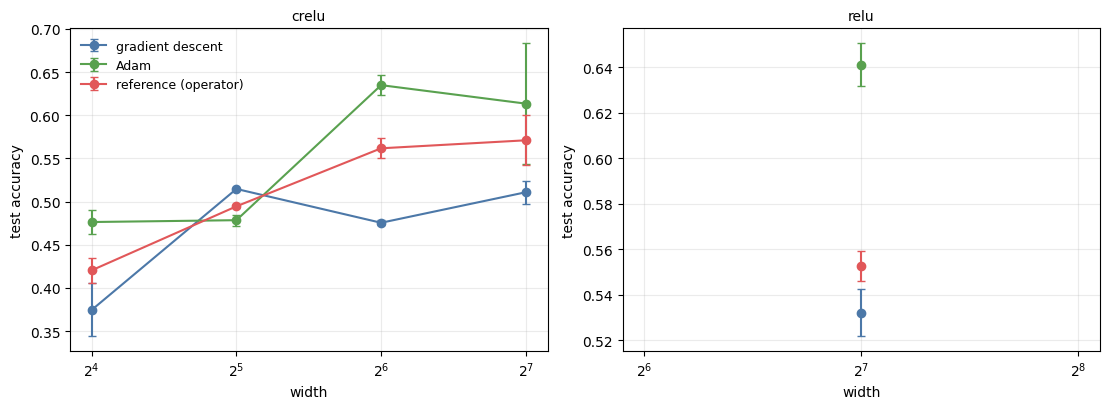

In [56]:
fig = analysis.fig_capacity(runs)
if fig is not None: save(fig, 'capacity'); plt.show()

In [57]:
print(f"{'arch':>6} {'width':>6} | " + ' '.join(f'{LABEL[a]:>22}' for a in ARMS))
for arch in ['crelu','relu']:
    ws = sorted({c['width'] for c,_,_ in select(runs, arch=arch)})
    for w in ws:
        row = f'{arch:>6} {w:>6} | '
        for arm in ARMS:
            got = analysis.pick(runs, arch, arm, width=w, steps=12000, by='stable')
            if not got: row += f"{'--':>22} "; continue
            h,g = got
            v = [analysis.stable_test(r) for _,r,_ in g]
            row += f'{np.mean(v):>8.3f} +-{np.std(v):<5.3f} (n={len(v)}) '
        print(row)

  arch  width |       gradient descent                   Adam   reference (operator)
 crelu     16 |    0.374 +-0.031 (n=3)    0.476 +-0.014 (n=3)    0.420 +-0.015 (n=3) 
 crelu     32 |    0.515 +-0.000 (n=1)    0.478 +-0.006 (n=3)    0.494 +-0.001 (n=2) 
 crelu     64 |    0.475 +-0.003 (n=2)    0.635 +-0.011 (n=2)    0.562 +-0.011 (n=2) 
 crelu    128 |    0.511 +-0.013 (n=5)    0.613 +-0.070 (n=5)    0.571 +-0.029 (n=5) 
  relu    128 |    0.532 +-0.010 (n=5)    0.641 +-0.010 (n=5)    0.553 +-0.007 (n=5) 
